## **Differences qasm, statevector, and unitary simulators in qiskit**

In [74]:
from qiskit import QuantumCircuit,transpile
from qiskit_aer import Aer, AerSimulator
from qiskit.visualization import array_to_latex
from qiskit.visualization import plot_histogram,plot_state_qsphere,plot_bloch_multivector,plot_state_hinton,plot_state_paulivec
from qiskit_aer.noise import NoiseModel, depolarizing_error
from math import pi
from qiskit.quantum_info import DensityMatrix, Operator
from qiskit.visualization import plot_state_city
print(Aer.backends())


[AerSimulator('aer_simulator'), AerSimulator('aer_simulator_statevector'), AerSimulator('aer_simulator_density_matrix'), AerSimulator('aer_simulator_stabilizer'), AerSimulator('aer_simulator_matrix_product_state'), AerSimulator('aer_simulator_extended_stabilizer'), AerSimulator('aer_simulator_unitary'), AerSimulator('aer_simulator_superop'), QasmSimulator('qasm_simulator'), StatevectorSimulator('statevector_simulator'), UnitarySimulator('unitary_simulator')]


## **Unitary Simulator**

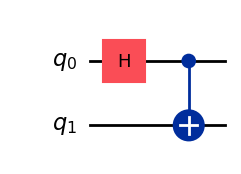

In [36]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.draw('mpl')


In [37]:
unitary_simulator = Aer.get_backend('unitary_simulator')
unitary_simulator_result = unitary_simulator.run(circuit).result()
unitary_simulator_result.data()


{'unitary': Operator([[ 0.70710678+0.00000000e+00j,  0.70710678-8.65956056e-17j,
             0.        +0.00000000e+00j,  0.        +0.00000000e+00j],
           [ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
             0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j],
           [ 0.        +0.00000000e+00j,  0.        +0.00000000e+00j,
             0.70710678+0.00000000e+00j,  0.70710678-8.65956056e-17j],
           [ 0.70710678+0.00000000e+00j, -0.70710678+8.65956056e-17j,
             0.        +0.00000000e+00j,  0.        +0.00000000e+00j]],
          input_dims=(2, 2), output_dims=(2, 2))}

In [38]:
array_to_latex(unitary_simulator_result.get_unitary())

<IPython.core.display.Latex object>

## **Statevector Simulator**

In [27]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)

statevector_simulator = Aer.get_backend('statevector_simulator')
statevector_simulator_result = statevector_simulator.run(circuit).result()
statevector_simulator_result.data()


{'statevector': Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
              0.70710678+0.j],
             dims=(2, 2))}

In [28]:
array_to_latex(statevector_simulator_result.get_statevector())

<IPython.core.display.Latex object>

In [29]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.save_statevector('breakpoint')
circuit.cx(0, 1)

statevector_simulator = Aer.get_backend('statevector_simulator')
statevector_simulator_result = statevector_simulator.run(circuit).result()
array_to_latex(statevector_simulator_result.data()['breakpoint'])


<IPython.core.display.Latex object>

## **QASM Simulator**

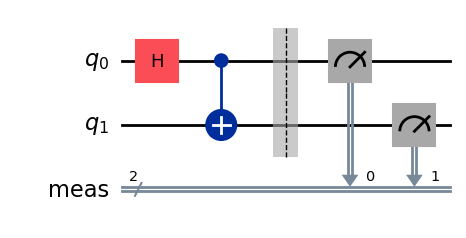

In [30]:
circuit = QuantumCircuit(2)
circuit.h(0)
circuit.cx(0, 1)
circuit.measure_all()  # <--
circuit.draw('mpl')


In [31]:
qasm_simulator = Aer.get_backend('qasm_simulator')
qasm_simulator_result = qasm_simulator.run(circuit).result()
qasm_simulator_result.data()


{'counts': {'0x3': 519, '0x0': 505}}

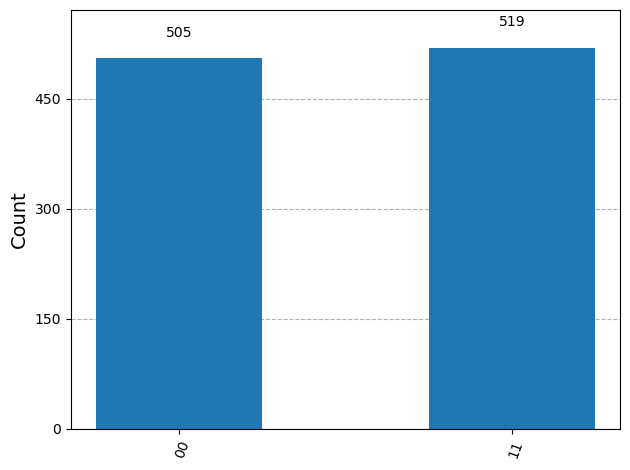

In [32]:
plot_histogram(qasm_simulator_result.get_counts())

In [33]:
memory_result = qasm_simulator.run(circuit, shots=10, memory=True).result()
memory_result.get_memory(circuit)

['11', '00', '00', '00', '00', '11', '00', '00', '11', '00']

In [47]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()
 
backend = Aer.get_backend("aer_simulator")
tqc = transpile(qc, backend)
job = backend.run(tqc, shots=1000)
result = job.result()
counts = result.get_counts(tqc)
print(counts)

{'11': 528, '00': 472}


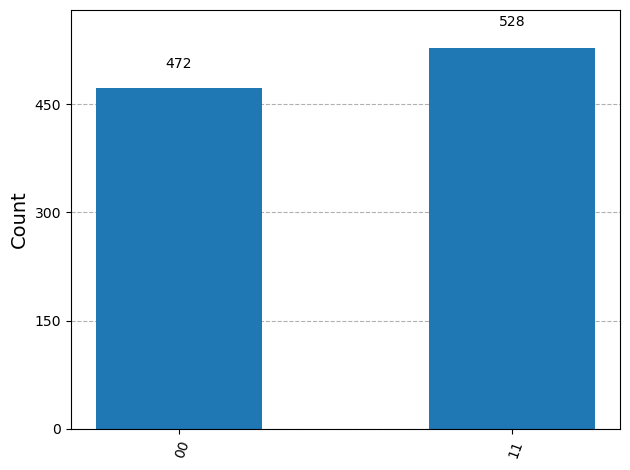

In [48]:
plot_histogram(result.get_counts())

In [49]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

backend = Aer.get_backend("aer_simulator")
qc.save_statevector()
tqc = transpile(qc, backend)
job = backend.run(tqc)
result = job.result()
statevector = result.get_statevector(tqc, 4)
print(statevector)

Statevector([0.7071+0.j, 0.    +0.j, 0.    +0.j, 0.7071+0.j],
            dims=(2, 2))


In [50]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)

backend = Aer.get_backend("aer_simulator")
qc.save_unitary()
tqc = transpile(qc, backend)
job = backend.run(tqc)
result = job.result()
unitary = result.get_unitary(qc, 4)
print(unitary)

Operator([[ 0.7071+0.j,  0.7071-0.j,  0.    +0.j,  0.    +0.j],
          [ 0.    +0.j,  0.    +0.j,  0.7071+0.j, -0.7071+0.j],
          [ 0.    +0.j,  0.    +0.j,  0.7071+0.j,  0.7071-0.j],
          [ 0.7071+0.j, -0.7071+0.j,  0.    +0.j,  0.    +0.j]],
         input_dims=(2, 2), output_dims=(2, 2))


In [51]:
array_to_latex(result.get_unitary())

<IPython.core.display.Latex object>

In [55]:
err_1 = depolarizing_error(0.95, 1)
err_2 = depolarizing_error(0.01, 2)
noise_model = NoiseModel()
noise_model.add_all_qubit_quantum_error(err_1,
                           ['u1', 'u2', 'u3'])
noise_model.add_all_qubit_quantum_error(err_2,
                                       ['cx'])

qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

backend = Aer.get_backend("aer_simulator")
backend.set_options(noise_model=noise_model)
tqc = transpile(qc, backend)
job = backend.run(tqc, shots=1000)
result = job.result()
counts = result.get_counts(tqc)
print(counts)


{'01': 2, '11': 477, '10': 3, '00': 518}


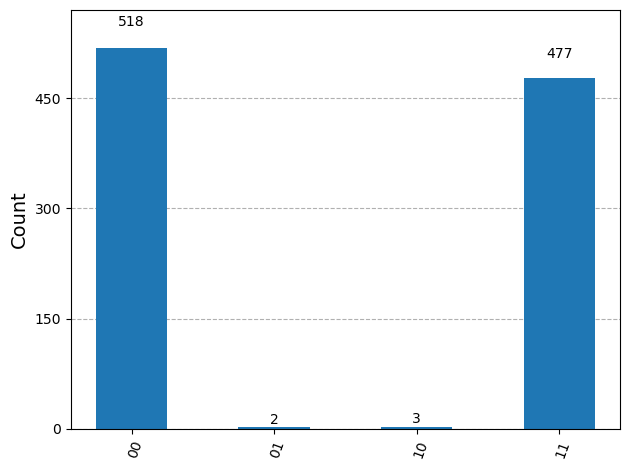

In [56]:
plot_histogram(result.get_counts())

In [58]:
# Your quantum circuit
qc = QuantumCircuit(2, 2)
qc.h(0)
qc.cx(0, 1)
qc.measure([0, 1], [0, 1])

# Initialize the simulator
simulator = AerSimulator()

# Transpile the circuit for the simulator
transpiled_qc = transpile(qc, simulator)

# Run the simulation
job = simulator.run(transpiled_qc, shots=1000)
result = job.result()
counts = result.get_counts(qc)
print(counts)


{'11': 501, '00': 499}


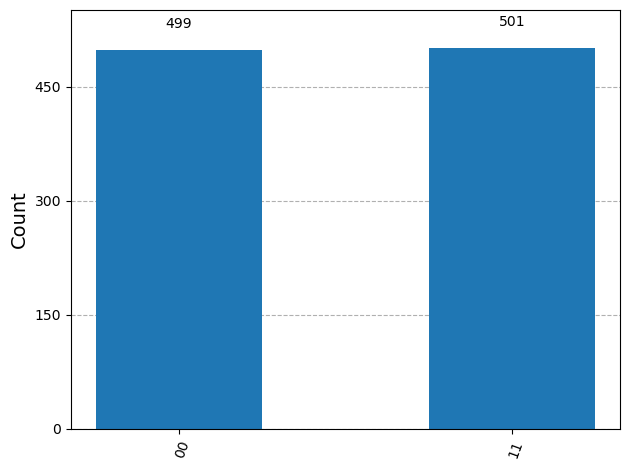

In [59]:
plot_histogram(result.get_counts())

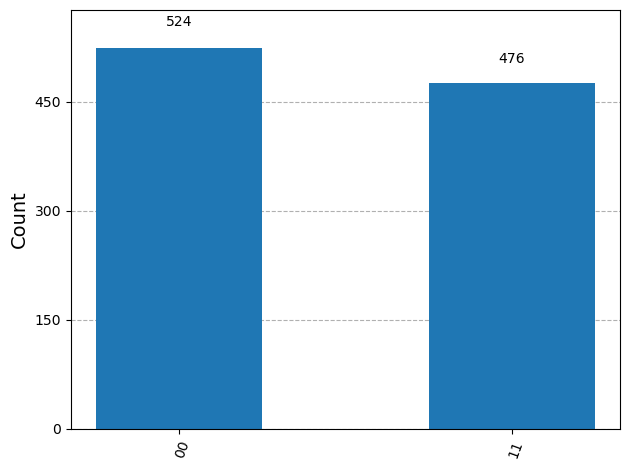

In [60]:
qc = QuantumCircuit(2)
qc.h(0)
qc.cx(0, 1)
qc.measure_all()

backend = Aer.get_backend("aer_simulator")
tqc = transpile(qc, backend)
job = backend.run(tqc, shots=1000)
result = job.result()
counts = result.get_counts(tqc)

plot_histogram(counts)


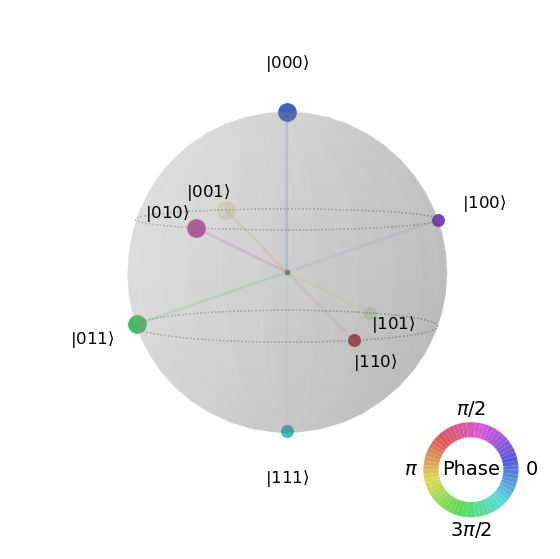

In [63]:
backend = Aer.get_backend("aer_simulator_statevector")

qc = QuantumCircuit(3)
qc.rx(pi, 0)
qc.ry(pi/8, 2)
qc.swap(0, 2)
qc.h(0)
qc.cp(pi/2,0, 1)
qc.cp(pi/4, 0, 2)
qc.h(1)
qc.cp(pi/2, 1, 2)
qc.h(2)
qc.save_statevector()

tqc = transpile(qc, backend)
job = backend.run(tqc)
result = job.result()
statevector = result.get_statevector()

plot_state_qsphere(statevector)

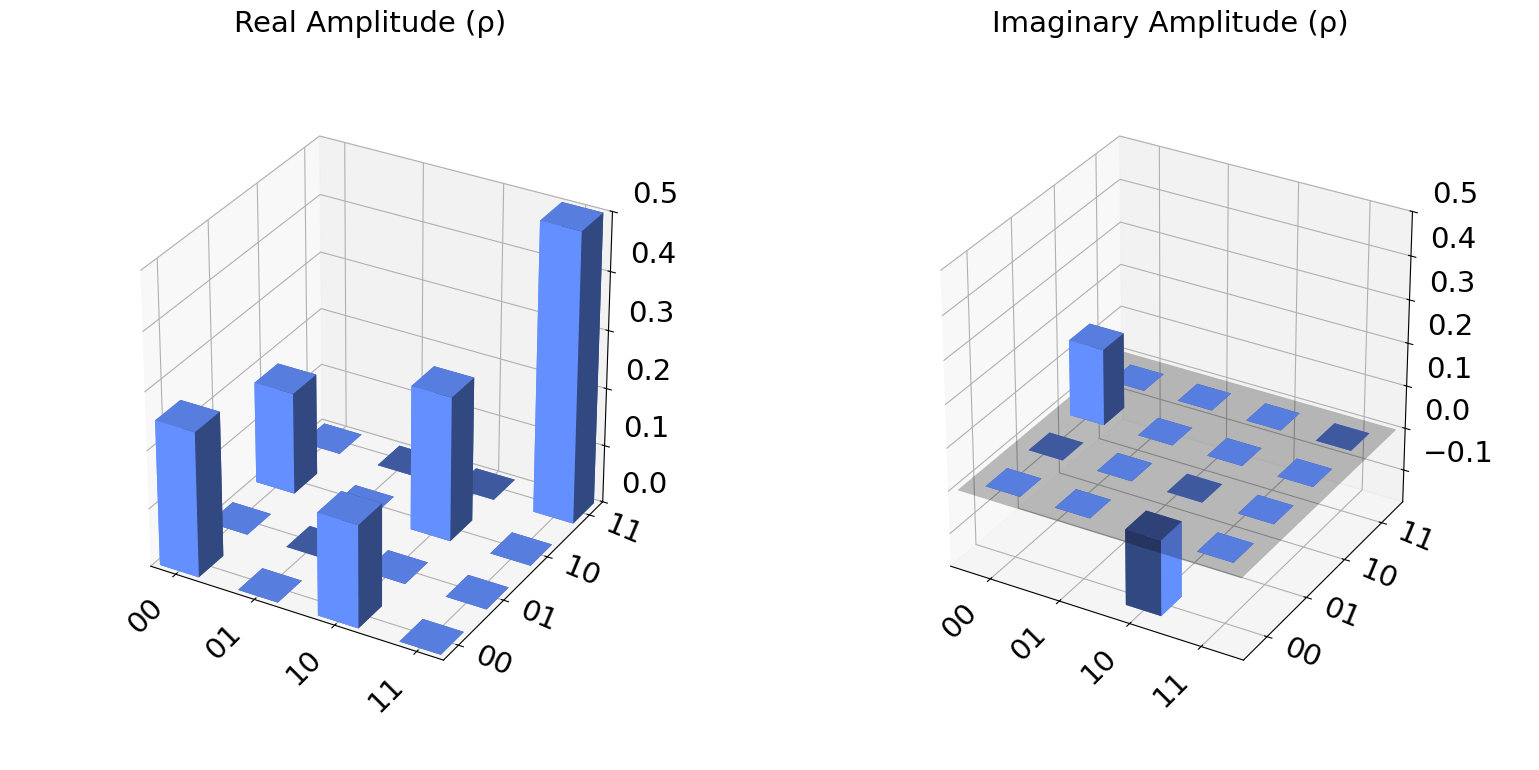

In [66]:
dens_mat = 0.5*DensityMatrix.from_label('11') +  0.5*DensityMatrix.from_label('+0')
tt_op = Operator.from_label('TT')
dens_mat = dens_mat.evolve(tt_op)
plot_state_city(dens_mat)

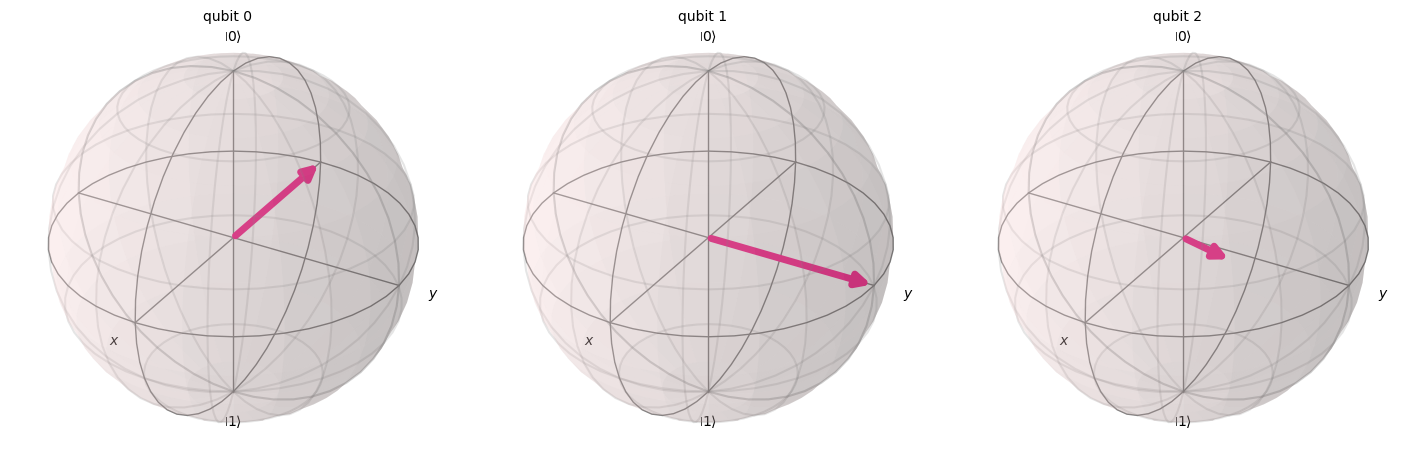

In [69]:
backend = Aer.get_backend("aer_simulator_statevector")

qc = QuantumCircuit(3)
qc.rx(pi, 0)
qc.ry(pi/8, 2)
qc.swap(0, 2)
qc.h(0)
qc.cp(pi/2,0, 1)
qc.cp(pi/4, 0, 2)
qc.h(1)
qc.cp(pi/2, 1, 2)
qc.h(2)
qc.save_statevector()

tqc = transpile(qc, backend)
job = backend.run(tqc)
result = job.result()
statevector = result.get_statevector()

plot_bloch_multivector(statevector)

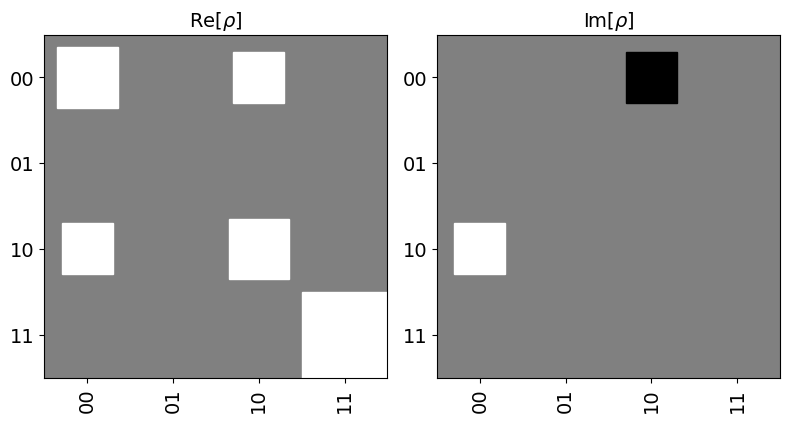

In [72]:
dens_mat = 0.5*DensityMatrix.from_label('11') +  0.5*DensityMatrix.from_label('+0')
tt_op = Operator.from_label('TT')
dens_mat = dens_mat.evolve(tt_op)

plot_state_hinton(dens_mat)

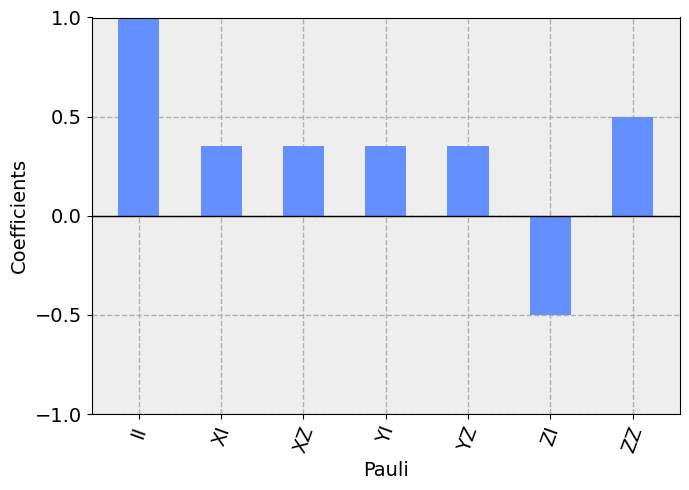

In [75]:
dens_mat = 0.5*DensityMatrix.from_label('11') +   0.5*DensityMatrix.from_label('+0')
tt_op = Operator.from_label('TT')
dens_mat = dens_mat.evolve(tt_op)

plot_state_paulivec(dens_mat)
